W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
현재 적용 폰트: NanumGothic
편의점 상품군 판매액지수 엑셀 파일 업로드


Saving 업태별상품군_판매액지수_2020100.0__20260621114155.xlsx to 업태별상품군_판매액지수_2020100.0__20260621114155 (1).xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


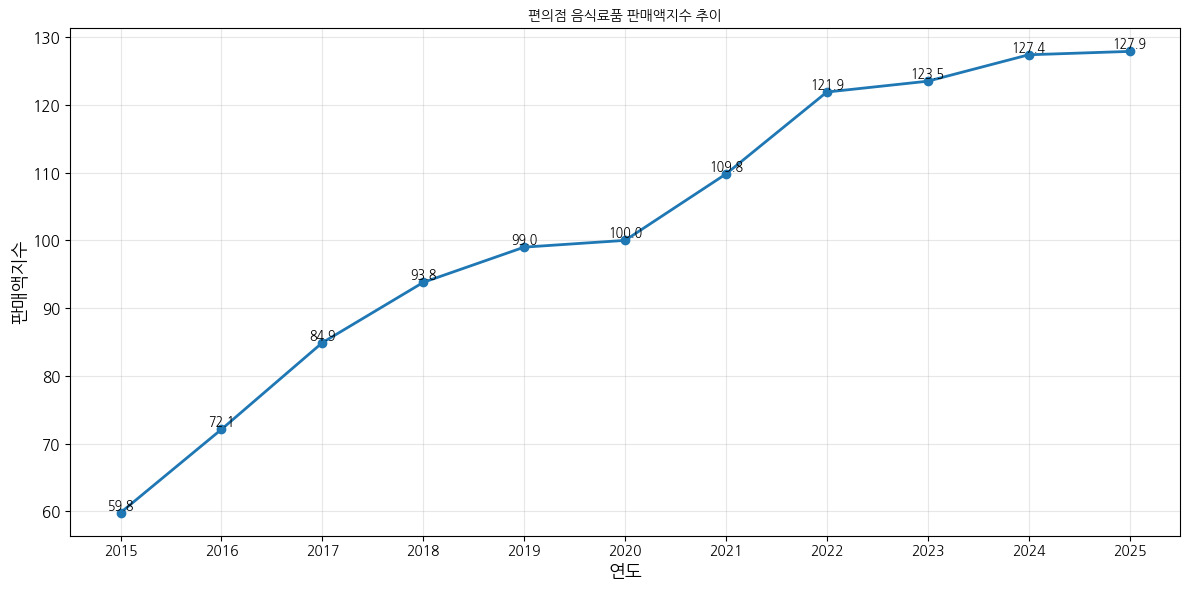

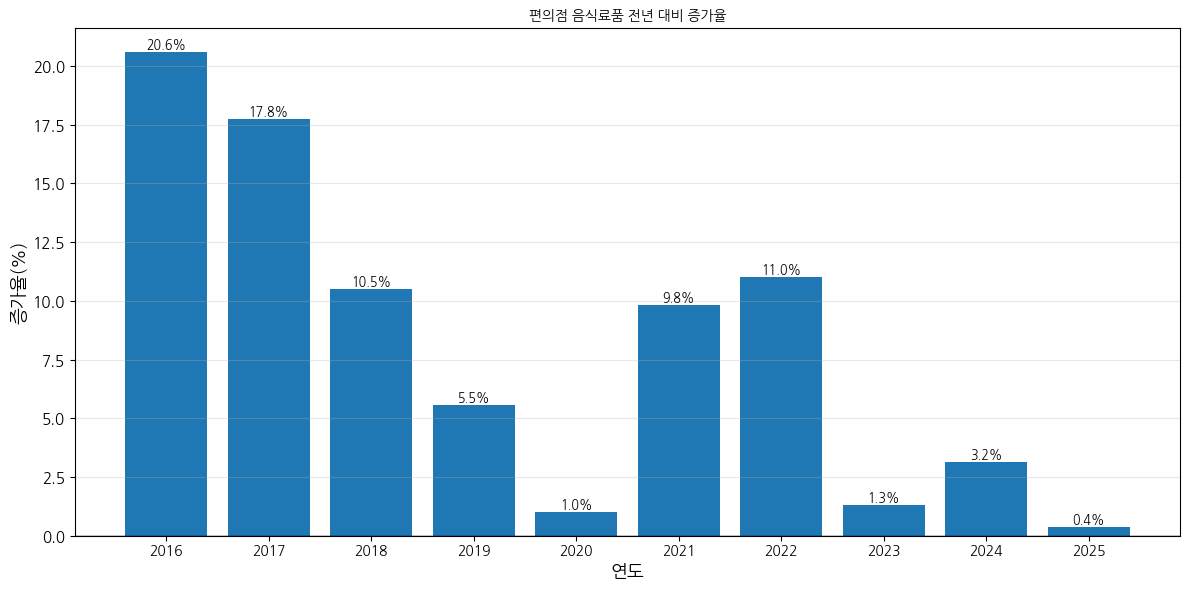


편의점 음식료품 파레토 분석 결과


,연도,판매액지수,전년대비증가율(%),비중(%),누적비율(%),등급
0,2025,127.9,0.392465,11.418623,11.418623,A
1,2024,127.4,3.157895,11.373984,22.792608,A
2,2023,123.5,1.312551,11.025801,33.818409,A
3,2022,121.9,11.020036,10.882957,44.701366,A
4,2021,109.8,9.800000,9.802696,54.504062,A
5,2020,100.0,1.010101,8.927774,63.431836,A
6,2019,99.0,5.543710,8.838497,72.270333,A
7,2018,93.8,10.482921,8.374252,80.644585,B
8,2017,84.9,17.753121,7.579680,88.224266,B
9,2016,72.1,20.568562,6.436925,94.661191,B


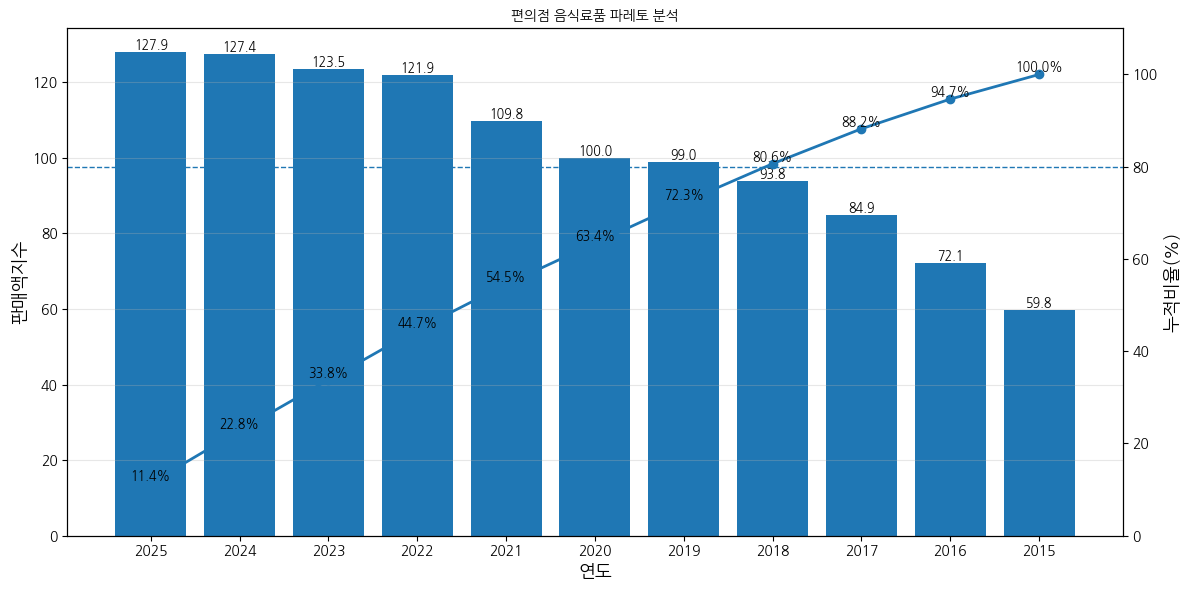

In [ ]:

# ============================================================
# 편의점 음식료품 판매액지수 분석
# 1) 판매액지수 추이
# 2) 전년 대비 증가율
# 3) 파레토 분석 수치
# 4) 파레토 분석 시각화
# Google Colab 실행용
# ============================================================

!apt-get -qq update
!apt-get -qq install -y fonts-nanum
!rm -rf ~/.cache/matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties
from google.colab import files

# ============================================================
# 1. 한글 폰트 강제 설정
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

print("현재 적용 폰트:", font_name)

# ============================================================
# 2. 파일 업로드
# ============================================================

print("=" * 60)
print("편의점 상품군 판매액지수 엑셀 파일 업로드")
print("=" * 60)

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# ============================================================
# 3. 엑셀 읽기
# ============================================================

raw = pd.read_excel(file_name, sheet_name="데이터", header=None)

# 실제 데이터 구조
# 0행: 연도
# 1행: 경상지수
# 2행: 음식료품 값

years = raw.iloc[0, 1:].astype(str).tolist()
values = pd.to_numeric(raw.iloc[2, 1:], errors="coerce")

df = pd.DataFrame({
    "연도": years,
    "판매액지수": values
})

df = df.dropna().reset_index(drop=True)

# ============================================================
# 4. 전년 대비 증가율 계산
# ============================================================

df["전년대비증가율(%)"] = df["판매액지수"].pct_change() * 100

# ============================================================
# 5. 판매액지수 추이 꺾은선 그래프
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    df["연도"],
    df["판매액지수"],
    marker="o",
    linewidth=2
)

plt.title(
    "편의점 음식료품 판매액지수 추이",
    fontsize=18,
    fontweight="bold",
    fontproperties=font_prop
)
plt.xlabel("연도", fontsize=13, fontproperties=font_prop)
plt.ylabel("판매액지수", fontsize=13, fontproperties=font_prop)
plt.xticks(fontsize=11, fontproperties=font_prop)
plt.yticks(fontsize=11)
plt.grid(alpha=0.3)

for x, y in zip(df["연도"], df["판매액지수"]):
    plt.text(
        x, y, f"{y:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontproperties=font_prop
    )

plt.tight_layout()
plt.show()

# ============================================================
# 6. 전년 대비 증가율 막대그래프
# ============================================================

growth_df = df.dropna(subset=["전년대비증가율(%)"]).copy()

plt.figure(figsize=(12, 6))

bars = plt.bar(
    growth_df["연도"],
    growth_df["전년대비증가율(%)"]
)

plt.title(
    "편의점 음식료품 전년 대비 증가율",
    fontsize=18,
    fontweight="bold",
    fontproperties=font_prop
)
plt.xlabel("연도", fontsize=13, fontproperties=font_prop)
plt.ylabel("증가율(%)", fontsize=13, fontproperties=font_prop)
plt.xticks(fontsize=11, fontproperties=font_prop)
plt.yticks(fontsize=11)
plt.axhline(0, color="black", linewidth=1)
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=9,
        fontproperties=font_prop
    )

plt.tight_layout()
plt.show()

# ============================================================
# 7. 파레토 분석
# 연도별 판매액지수를 큰 순서대로 정렬
# 누적비율 기준으로 A/B/C 등급 분류
# A: 누적 80% 이하
# B: 누적 95% 이하
# C: 나머지
# ============================================================

pareto = df.sort_values("판매액지수", ascending=False).reset_index(drop=True)

pareto["비중(%)"] = pareto["판매액지수"] / pareto["판매액지수"].sum() * 100
pareto["누적비율(%)"] = pareto["비중(%)"].cumsum()

def abc_class(x):
    if x <= 80:
        return "A"
    elif x <= 95:
        return "B"
    else:
        return "C"

pareto["등급"] = pareto["누적비율(%)"].apply(abc_class)

# ============================================================
# 8. 파레토 분석 수치 출력
# ============================================================

print("\n" + "=" * 60)
print("편의점 음식료품 파레토 분석 결과")
print("=" * 60)

display(pareto)

# ============================================================
# 9. 파레토 분석 시각화
# x축: 연도
# y축: 판매액지수
# 보조축: 누적비율
# ============================================================

fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(
    pareto["연도"],
    pareto["판매액지수"],
    label="판매액지수"
)

ax1.set_xlabel("연도", fontsize=13, fontproperties=font_prop)
ax1.set_ylabel("판매액지수", fontsize=13, fontproperties=font_prop)
ax1.tick_params(axis="x", labelsize=11)
ax1.tick_params(axis="y", labelsize=11)

for label in ax1.get_xticklabels():
    label.set_fontproperties(font_prop)

for label in ax1.get_yticklabels():
    label.set_fontproperties(font_prop)

for bar in bars:
    value = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontproperties=font_prop
    )

ax2 = ax1.twinx()

ax2.plot(
    pareto["연도"],
    pareto["누적비율(%)"],
    marker="o",
    linewidth=2,
    label="누적비율"
)

ax2.axhline(80, linestyle="--", linewidth=1)
ax2.set_ylabel("누적비율(%)", fontsize=13, fontproperties=font_prop)
ax2.set_ylim(0, 110)

for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)

for x, y in zip(pareto["연도"], pareto["누적비율(%)"]):
    ax2.text(
        x, y,
        f"{y:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontproperties=font_prop
    )

plt.title(
    "편의점 음식료품 파레토 분석",
    fontsize=18,
    fontweight="bold",
    fontproperties=font_prop
)

ax1.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()